<a href="https://colab.research.google.com/github/EdmundoMarquez/AnalisisDatos_IA/blob/main/Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

In [94]:
#Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [95]:
# Importar dataset
df_penguins = sns.load_dataset('penguins')
print(df_penguins)

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1         3800.0  Female  
2     

## Análisis descriptivo

In [96]:
# Información del dataset "penguins"
df_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Datos únicos de tipos clasificatorios (object)

In [97]:
df_penguins['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [98]:
df_penguins['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [99]:
df_penguins['sex'].unique()

array(['Male', 'Female', nan], dtype=object)

In [100]:
#Mostrar el resumen estadístico
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


###Análisis Univariable

In [101]:
#Definir medidas de tendencia central (Peso g)
media = round(df_penguins["body_mass_g"].mean(), 2)
mediana = round(df_penguins["body_mass_g"].median(), 2)
moda = round(df_penguins["body_mass_g"].mode().iloc[0], 2)

print(f"Las MTC son: media {media}, mediana {mediana} y moda {moda}")

Las MTC son: media 4201.75, mediana 4050.0 y moda 3800.0


In [102]:
import numpy as np
# Definir medidas de dispersión (Peso g)
x = range(len(df_penguins["body_mass_g"]))
y = df_penguins["body_mass_g"]
std = round(np.std(df_penguins["body_mass_g"]), 2)
prop_prob = round((std / media) * 100, 1)

# Calcular percentiles ignorando valores NaN
percentil = np.percentile(df_penguins["body_mass_g"].dropna(), [25, 50, 75])
q_1 = round(percentil[0], 2)
q_3 = round(percentil[2], 2)
iqr = round(q_3 - q_1, 2)

print(f"La media es {media} y la desviación estándar es {std}")
print(f"La proporción de probabilidad es {prop_prob}%")
print(f"EL IQR es {iqr} y los percentiles {percentil}")

La media es 4201.75 y la desviación estándar es 800.78
La proporción de probabilidad es 19.1%
EL IQR es 1200.0 y los percentiles [3550. 4050. 4750.]


Visualización

In [103]:
# Definir variables
mtc_datos = [media, mediana, moda]
mtc_nombres = ["Media", "Mediana", "Moda"]
mtc_colores = ["purple", "blue", "cyan"]
mtc_config = zip(mtc_datos, mtc_nombres, mtc_colores)

std_datos = [media, media + std, media - std]
std_nombres = ["Media", "Desviación Estándar", None]
std_colores = ["purple", "blue", "cyan"]
std_config = zip(std_datos, std_nombres, std_colores)

Text(0.5, 0, 'Peso (g)')

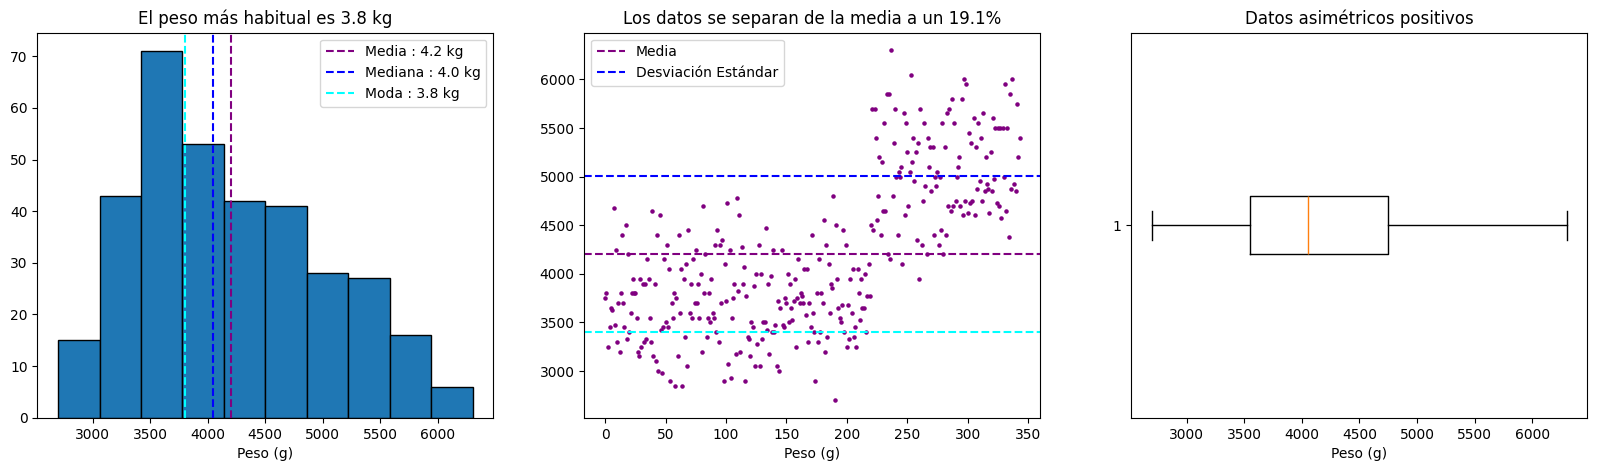

In [104]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
#Histograma
ax[0].hist(df_penguins["body_mass_g"], edgecolor="black")
for dato, nombre, color in mtc_config:
  ax[0].axvline(x = dato, c = color, linestyle="--", label=f"{nombre} : {round(dato / 1000, 1)} kg")
ax[0].set_title(f"El peso más habitual es {round(moda / 1000, 1)} kg")
ax[0].set_xlabel("Peso (g)")
ax[0].legend()

#Dispersión
ax[1].scatter(x, y, s=5, color="purple")
for dato, nombre, color in std_config:
  ax[1].axhline(y = dato, c = color, linestyle="--", label=nombre)
ax[1].set_title(f"Los datos se separan de la media a un {prop_prob}%")
ax[1].set_xlabel("Peso (g)")
ax[1].legend()

#Boxplot
ax[2].boxplot(df_penguins["body_mass_g"].dropna(), label=f"Mediana: {mediana} \nIQR: {iqr}", vert=False)
ax[2].set_title("Datos asimétricos positivos")
ax[2].set_xlabel("Peso (g)")

### Análisis Multivariable

In [105]:
# Definir variables
columnas = ["body_mass_g", "bill_depth_mm", "flipper_length_mm"]
corr = df_penguins[columnas].corr()
long_col = len(columnas)

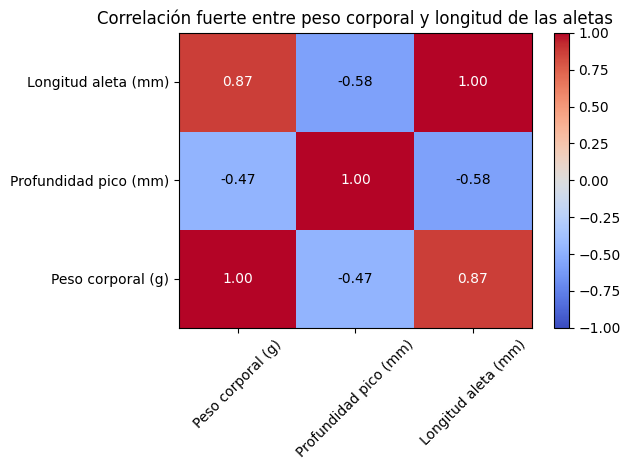

In [106]:
# Visualizar mapa de calor
heatmap = plt.pcolor(corr, cmap="coolwarm", vmin = -1, vmax = 1)
plt.title("Correlación fuerte entre peso corporal y longitud de las aletas")

nombre_columnas = ["Peso corporal (g)", "Profundidad pico (mm)", "Longitud aleta (mm)"]

plt.xticks(np.arange(0.5, long_col, 1), nombre_columnas, rotation=45)
plt.yticks(np.arange(0.5, long_col), nombre_columnas)

for i in range(long_col):
  for j in range(long_col):
    plt.text(j + 0.5, i + 0.5, f"{corr.iloc[i, j]:.2f}",
    ha = "center", va = "center",
    color = "white" if abs(corr.iloc[i,j]) > 0.6 else "black")
plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

### Análisis Bivariable

In [107]:
# Definir variables
corr_peso_aleta_long = round(df_penguins["body_mass_g"].corr(df_penguins["bill_length_mm"]), 2)
corr_aleta_pico_long = round(df_penguins["flipper_length_mm"].corr(df_penguins["bill_length_mm"]), 2)
corr_peso_pico_long = round(df_penguins["body_mass_g"].corr(df_penguins["bill_length_mm"]), 2)

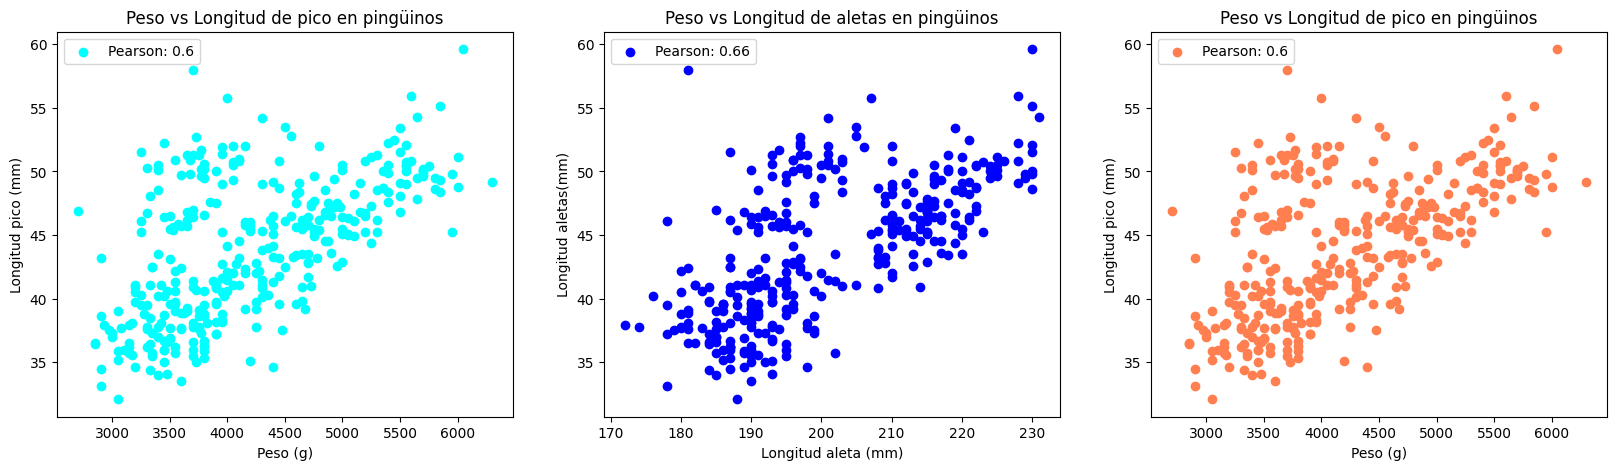

In [136]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].scatter(data = df_penguins, x = "body_mass_g", y = "bill_length_mm", color="cyan", label=f"Pearson: {corr_peso_aleta_long}")
ax[0].set_xlabel("Peso (g)")
ax[0].set_ylabel("Longitud pico (mm)")
ax[0].set_title(f"Peso vs Longitud de pico en pingüinos")
ax[0].legend()

ax[1].scatter(data = df_penguins, x = "flipper_length_mm", y = "bill_length_mm", color="blue", label=f"Pearson: {corr_aleta_pico_long}")
ax[1].set_xlabel("Longitud aleta (mm)")
ax[1].set_ylabel("Longitud aletas(mm)")
ax[1].set_title(f"Peso vs Longitud de aletas en pingüinos")
ax[1].legend()

ax[2].scatter(data = df_penguins, x = "body_mass_g", y = "bill_length_mm", color="coral", label=f"Pearson: {corr_peso_pico_long}")
ax[2].set_xlabel("Peso (g)")
ax[2].set_ylabel("Longitud pico (mm)")
ax[2].set_title(f"Peso vs Longitud de pico en pingüinos")
ax[2].legend()


## Aprendizaje Estadístico

In [109]:
# Importar módulo
from scipy import stats

### Hipótesis y Prueba de T Student

In [110]:
# Separación de grupos
pinguinos_macho_peso = df_penguins[df_penguins["sex"] == "Male"]["body_mass_g"]
pinguinos_hembra_peso = df_penguins[df_penguins["sex"] == "Female"]["body_mass_g"]

In [111]:
t_stat, p_value = stats.ttest_ind(pinguinos_macho_peso, pinguinos_hembra_peso)
print(f"Estadistico T: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Estadistico T: 8.5417
p-value: 0.0000


In [112]:
# Interpretación automática
if p_value < 0.01:
  print("Conclusión: Rechazamos la hipótesis nula (H0)")
  print("Existe una diferencia muy significativa entre la propina de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
  print("Conclusión: Rechazamos la hipótesis nula (H0)")
  print("Existe una diferencia altamente significativa entre la propina de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.1:
  print("Conclusión: No podemos rechazar la hipotesis nula (H0)")
  print("No existe una diferencia altamente significativa entre la propina de ambos grupos.")
else:
  print("Conclusión: No podemos rechazar la hipotesis nula (H0)")
  print("No hay evidencia suficiente para decir que las propinas son diferentes.")

Conclusión: Rechazamos la hipótesis nula (H0)
Existe una diferencia muy significativa entre la propina de ambos grupos.


### Regresión lineal entre longitud pico y peso

In [127]:
# Definir regresión lineal
x = df_penguins["bill_length_mm"].dropna()
y = df_penguins["body_mass_g"].dropna()
linear_regression = np.polyfit(x, y, deg=1)
beta, alpha = linear_regression
print(f"y={beta}, x + {alpha}")

y=87.41527705287555, x + 362.3067216539214


In [128]:
# Realizar algoritmo de descenso de gradiente
steps = 0.00025
theta_0 = 0
theta_1 = 0

perdida = []
iteraciones = 100

for i in range(iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y - y_pred)**2).mean()
  perdida.append(error)

  d_theta_0 = (2 / len(x)) * np.sum(y_pred - y)
  d_theta_1 = (2 / len(x)) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - steps * d_theta_0
  theta_1 = theta_1 - steps * d_theta_1

print(f"y = {theta_1} x = {theta_0}")

y = 95.48493674416082 x = 2.4141228422085343


In [132]:
# Predicción de valores usando el algoritmo de
# descenso de gradiente

value_user = float(input("Agrega la longitud del pico (mm) para predecir peso: "))
y_pred = round(theta_1 * value_user + theta_0, 2)
print(f"El peso del pingüino es de {round(y_pred / 1000, 4)} kg")


Agrega la longitud del pico (mm) para predecir peso: 36
El peso del pingüino es de 3.4399 kg


In [137]:
# Las predicciones se acercan cuando el peso se ubica dentro de la moda
print(f"Moda: {moda} Pico (mm): {df_penguins["bill_length_mm"].iloc[4]}" +
      f" Peso (g): {df_penguins["body_mass_g"].iloc[4]}")

Moda: 3800.0 Pico (mm): 36.7 Peso (g): 3450.0


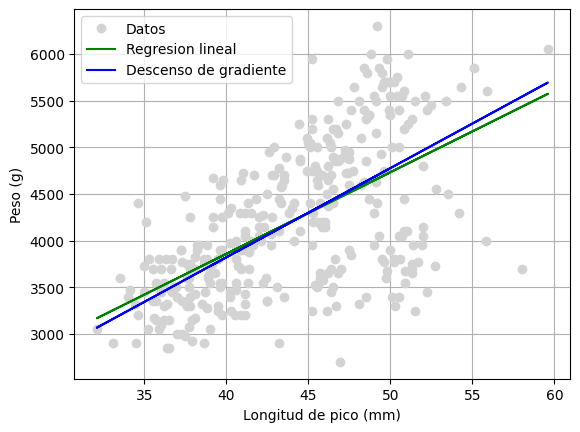

In [134]:
plt.plot(x, y, "o", color = "lightgray", label="Datos")
plt.plot(x, beta * x + alpha, color = "green", label = "Regresion lineal")
plt.plot(x, theta_1 * x + theta_0, color = "blue", label = "Descenso de gradiente")
plt.xlabel("Longitud de pico (mm)")
plt.ylabel("Peso (g)")
plt.legend()
plt.grid()
plt.show()

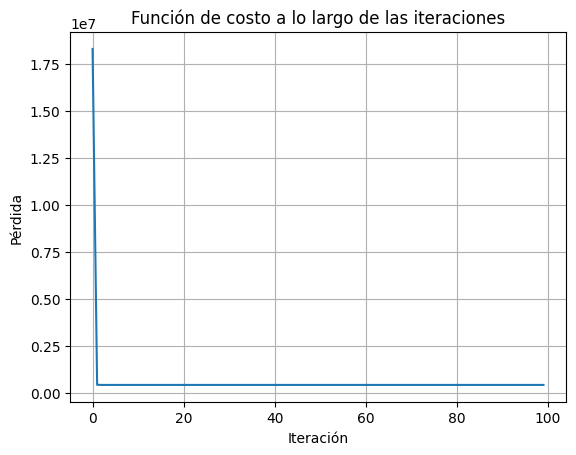

In [135]:
# Visualizar función de costo
plt.plot(perdida)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Función de costo a lo largo de las iteraciones")
plt.grid(True)
plt.show()